## LSTM

A **Long Short-Term Memory (LSTM) Network** is a special type of recurrent neural network (RNN) capable of learning long-term dependencies in data. Unlike traditional RNNs, LSTMs are designed to remember information for extended periods, making them particularly suitable for tasks involving sequential data, such as natural language, where the context of previous words is crucial for understanding current meaning.

LSTMs solve the vanishing gradient problem that affects RNNs by incorporating 'memory cells.' These cells have 'gates' (input gate, forget gate, output gate) that control the flow of information:

*   **Forget Gate:** Decides which information to discard from the cell state.
*   **Input Gate:** Decides what new information to store in the cell state.
*   **Output Gate:** Decides what part of the cell state will be output.

In this notebook, we are building and training a fake news classifier model using an LSTM network. The process is as follows:

1.  **Data Loading and Preprocessing:** We load a dataset of news (real and fake) and preprocess the text to prepare it for the model.
2.  **Embedding Generation:** We use a `SentenceTransformer` model to convert each news sentence into numerical vectors (embeddings).
3.  **Dataset Preparation:** The generated embeddings are organized into a suitable format for PyTorch training.
4.  **LSTM Model Definition:** We create a bidirectional LSTM network (capable of processing sequences in both directions to capture richer context)
5.  **Training:** We train the LSTM model using an optimizer, a loss function, and a scheduler to adjust the model's weights and improve its performance.
6.  **Evaluation**
7.  **Prediction:** Finally, we use the trained model to predict whether a new news article is fake or real.

### **Library Installation**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import itertools
from sklearn.metrics import classification_report

### **Data Loading and Preprocessing**
This section loads the 'True.csv' and 'Fake.csv' datasets, assigns labels, combines them into a single DataFrame, and then splits the data into training and testing sets.

In [6]:
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

df_true["label"] = 1
df_fake["label"] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)
df["text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()
df = df[["text", "label"]].sample(frac=1, random_state=42).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 35,918  |  Test: 8,980


### **Embedding Generation**
Here, a `SentenceTransformer` model is loaded to convert text into numerical embeddings, more specifically, the model *all-MiniLM-L6-v2* Custom functions `text_to_chunks` and `encode_texts` are defined to process and generate embeddings for the training and testing datasets.

In [7]:
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MAX_CHUNKS  = 10
EMBED_DIM   = 384

embed_model = SentenceTransformer(EMBED_MODEL)
embed_model.eval()   # congelado

def text_to_chunks(text: str, max_chunks: int = MAX_CHUNKS) -> list[str]:
    """Divide el texto en oraciones y toma las primeras max_chunks."""
    import re
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    if len(sentences) == 0:
        sentences = [text[:500]]
    return sentences[:max_chunks]

def encode_texts(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """
    Convierte una lista de noticias en tensores de forma (N, MAX_CHUNKS, EMBED_DIM).
    Hace padding con ceros si la noticia tiene menos chunks que MAX_CHUNKS.
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        batch_embeddings = []

        for text in batch:
            chunks = text_to_chunks(text)

            # Embeddings de cada chunk: shape (n_chunks, 384)
            with torch.no_grad():
                embs = embed_model.encode(chunks, convert_to_numpy=True)

            # Padding hasta MAX_CHUNKS si faltan chunks
            if len(embs) < MAX_CHUNKS:
                pad = np.zeros((MAX_CHUNKS - len(embs), EMBED_DIM), dtype=np.float32)
                embs = np.vstack([embs, pad])

            batch_embeddings.append(embs)

        all_embeddings.extend(batch_embeddings)

        if (i // batch_size) % 5 == 0:
            print(f"  Procesadas {min(i + batch_size, len(texts)):,} / {len(texts):,}")

    return np.array(all_embeddings, dtype=np.float32)  # (N, MAX_CHUNKS, EMBED_DIM)


print("Generando embeddings de train...")
X_train_emb = encode_texts(X_train)

print("Generando embeddings de test...")
X_test_emb = encode_texts(X_test)

print(f"\nShape train: {X_train_emb.shape}")  # (N, 10, 384)
print(f"Shape test:  {X_test_emb.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings de train...
  Procesadas 64 / 35,918
  Procesadas 384 / 35,918
  Procesadas 704 / 35,918
  Procesadas 1,024 / 35,918
  Procesadas 1,344 / 35,918
  Procesadas 1,664 / 35,918
  Procesadas 1,984 / 35,918
  Procesadas 2,304 / 35,918
  Procesadas 2,624 / 35,918
  Procesadas 2,944 / 35,918
  Procesadas 3,264 / 35,918
  Procesadas 3,584 / 35,918
  Procesadas 3,904 / 35,918
  Procesadas 4,224 / 35,918
  Procesadas 4,544 / 35,918
  Procesadas 4,864 / 35,918
  Procesadas 5,184 / 35,918
  Procesadas 5,504 / 35,918
  Procesadas 5,824 / 35,918
  Procesadas 6,144 / 35,918
  Procesadas 6,464 / 35,918
  Procesadas 6,784 / 35,918
  Procesadas 7,104 / 35,918
  Procesadas 7,424 / 35,918
  Procesadas 7,744 / 35,918
  Procesadas 8,064 / 35,918
  Procesadas 8,384 / 35,918
  Procesadas 8,704 / 35,918
  Procesadas 9,024 / 35,918
  Procesadas 9,344 / 35,918
  Procesadas 9,664 / 35,918
  Procesadas 9,984 / 35,918
  Procesadas 10,304 / 35,918
  Procesadas 10,624 / 35,918
  Procesadas 10,944 

### **Dataset and DataLoader Preparation**
This cell defines a custom PyTorch `Dataset` class to handle the embeddings and labels. It then creates `DataLoader` instances for both training and testing, which will be used to feed data into the model in batches.

In [8]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings: np.ndarray, labels: list):
        self.X = torch.tensor(embeddings, dtype=torch.float32)
        self.y = torch.tensor(labels,     dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmbeddingDataset(X_train_emb, y_train)
test_dataset  = EmbeddingDataset(X_test_emb,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

### **LSTM Model Definition**
This section defines the `LSTMFakeNewsClassifier` model, a bidirectional LSTM network with a classifier head. It also sets up the device (GPU/CPU) for training and prints the total number of trainable parameters.

In [9]:
class LSTMFakeNewsClassifier(nn.Module):
    def __init__(self, embed_dim=384, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,    # lee los chunks en ambas direcciones
            dropout=dropout if num_layers > 1 else 0,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, 64),  # *2 por bidireccional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, MAX_CHUNKS, EMBED_DIM)
        lstm_out, _ = self.lstm(x)         # (batch, MAX_CHUNKS, hidden*2)
        last_out = lstm_out[:, -1, :]      # (batch, hidden*2)
        return self.classifier(last_out).squeeze(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

model = LSTMFakeNewsClassifier().to(device)

total = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {total:,}")

Usando: cuda
Parámetros entrenables: 938,113


### **Model Training**
This cell contains the main training loop for the LSTM model. It initializes the optimizer, learning rate scheduler, and loss function. It iterates through epochs, performing training and validation, and implements early stopping to save the best performing model.

In [13]:
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
criterion = nn.BCELoss()

EPOCHS     = 15
best_f1    = 0
patience   = 4
no_improve = 0

# Historial completo de métricas
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_f1":   [], "val_f1":   [],
    "val_auc":    [], "lr":       [],
}

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        train_preds.extend((preds.detach().cpu().numpy() > 0.5).astype(int))
        train_labels.extend(y_batch.cpu().numpy().astype(int))

    # ── Validación ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0
    val_preds, val_probs, val_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs = model(X_batch)
            loss  = criterion(probs, y_batch)

            val_loss   += loss.item()
            val_probs.extend(probs.cpu().numpy())
            val_preds.extend((probs.cpu().numpy() > 0.5).astype(int))
            val_labels.extend(y_batch.cpu().numpy().astype(int))

    # ── Métricas ─────────────────────────────────────────────────────────────
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss   / len(test_loader)
    t_acc  = sum(p == l for p, l in zip(train_preds, train_labels)) / len(train_labels)
    v_acc  = sum(p == l for p, l in zip(val_preds,   val_labels))   / len(val_labels)
    t_f1   = f1_score(train_labels, train_preds, average="weighted")
    v_f1   = f1_score(val_labels,   val_preds,   average="weighted")
    v_auc  = roc_auc_score(val_labels, val_probs)
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["train_f1"].append(t_f1)
    history["val_f1"].append(v_f1)
    history["val_auc"].append(v_auc)
    history["lr"].append(lr_now)

    scheduler.step(v_f1)

    print(f"Época {epoch:02d} | "
          f"Loss {t_loss:.4f}/{v_loss:.4f} | "
          f"Acc {t_acc:.4f}/{v_acc:.4f} | "
          f"F1 {t_f1:.4f}/{v_f1:.4f} | "
          f"AUC {v_auc:.4f} | "
          f"LR {lr_now:.2e}")

    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), "lstm_fakenews_best.pt")
        no_improve = 0
        print(f"           → Modelo guardado (F1: {best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping en época {epoch}")
            break

Época 01 | Loss 0.0302/0.0624 | Acc 0.9898/0.9822 | F1 0.9898/0.9822 | AUC 0.9985 | LR 1.00e-03
           → Modelo guardado (F1: 0.9822)
Época 02 | Loss 0.0297/0.0463 | Acc 0.9894/0.9856 | F1 0.9894/0.9856 | AUC 0.9986 | LR 1.00e-03
           → Modelo guardado (F1: 0.9856)
Época 03 | Loss 0.0286/0.0567 | Acc 0.9903/0.9842 | F1 0.9903/0.9842 | AUC 0.9986 | LR 1.00e-03
Época 04 | Loss 0.0265/0.0634 | Acc 0.9908/0.9834 | F1 0.9908/0.9834 | AUC 0.9987 | LR 1.00e-03
Época 05 | Loss 0.0261/0.0569 | Acc 0.9912/0.9851 | F1 0.9912/0.9851 | AUC 0.9987 | LR 1.00e-03
Época 06 | Loss 0.0168/0.0556 | Acc 0.9943/0.9857 | F1 0.9943/0.9857 | AUC 0.9989 | LR 5.00e-04
           → Modelo guardado (F1: 0.9857)
Época 07 | Loss 0.0146/0.0530 | Acc 0.9956/0.9861 | F1 0.9956/0.9861 | AUC 0.9988 | LR 5.00e-04
           → Modelo guardado (F1: 0.9861)
Época 08 | Loss 0.0137/0.0611 | Acc 0.9958/0.9853 | F1 0.9958/0.9853 | AUC 0.9988 | LR 5.00e-04
Época 09 | Loss 0.0149/0.0509 | Acc 0.9949/0.9862 | F1 0.9949/0.

### **Model Evaluation and Visualization**
After training, this section loads the best saved model and performs a comprehensive evaluation on the test set. It generates various plots including training curves, confusion matrices, ROC and Precision-Recall curves, and a distribution of predicted probabilities. A detailed classification report is also printed.

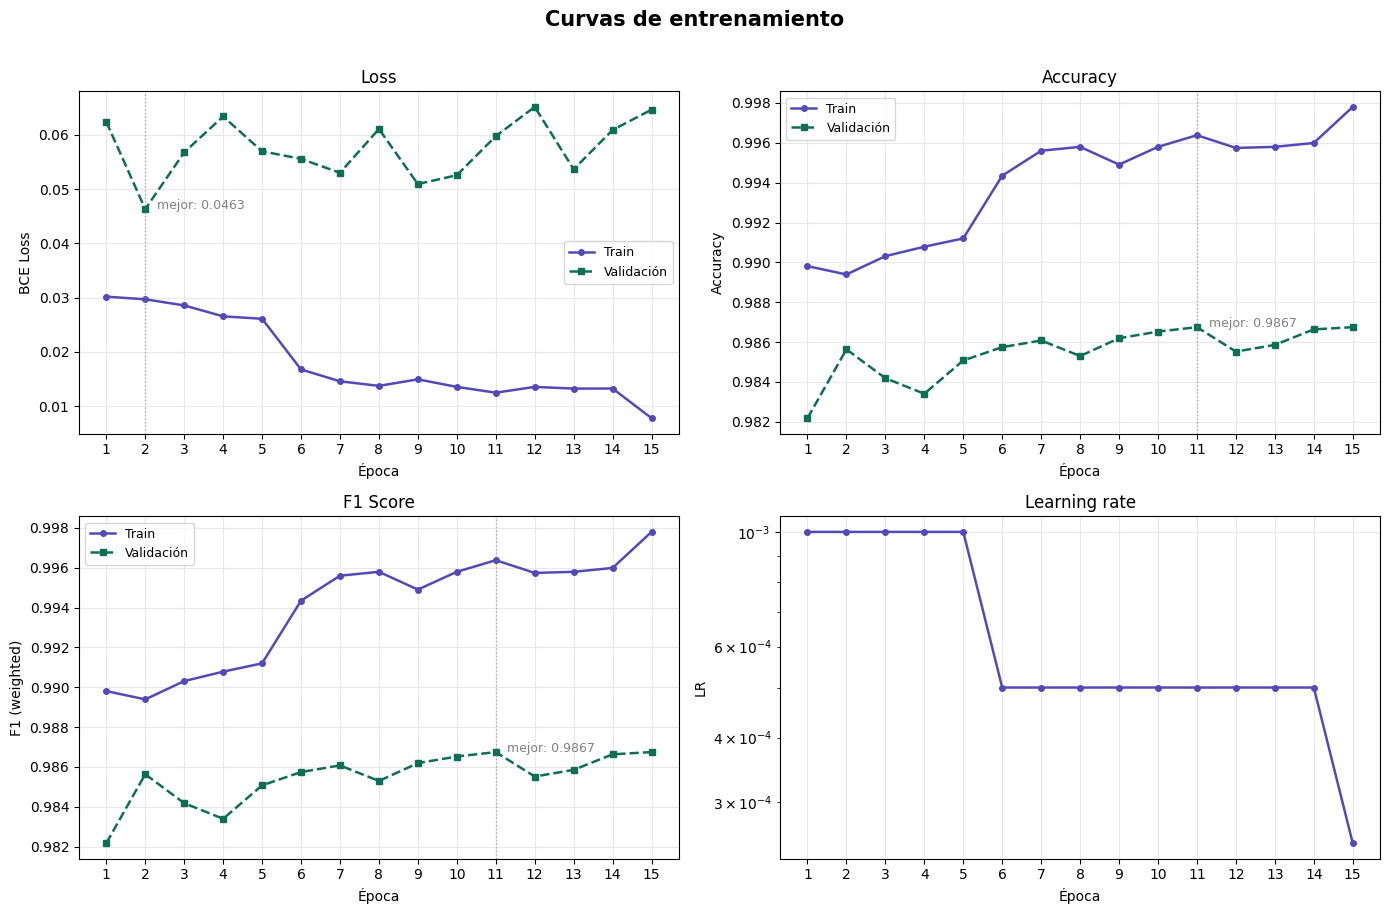

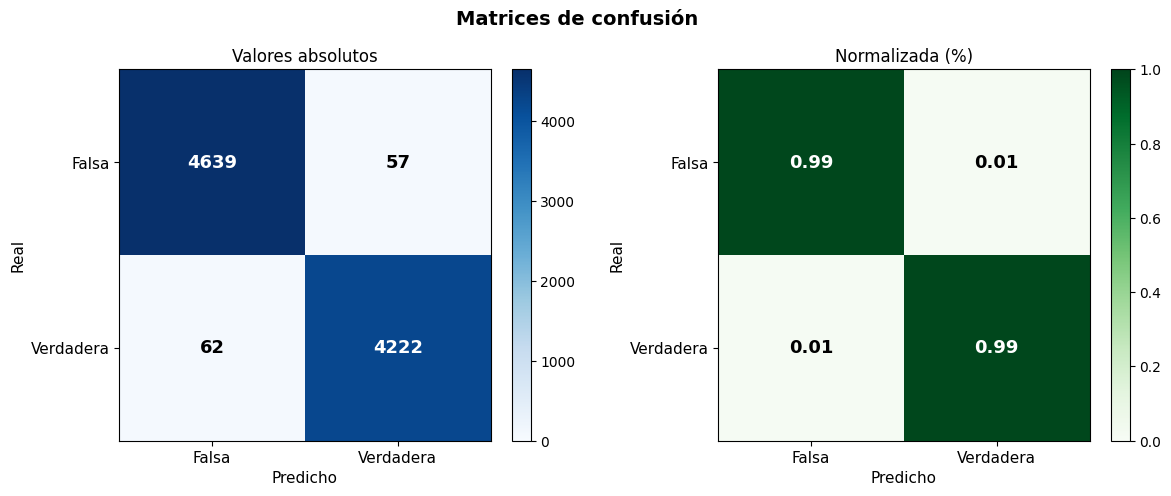

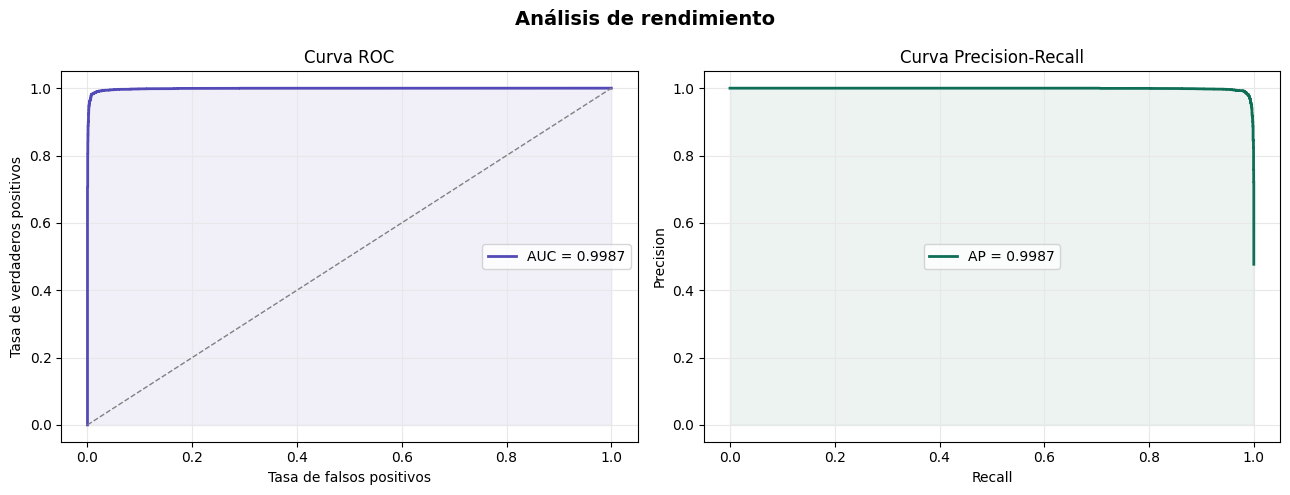

REPORTE FINAL DE CLASIFICACIÓN
              precision    recall  f1-score   support

       Falsa     0.9868    0.9879    0.9873      4696
   Verdadera     0.9867    0.9855    0.9861      4284

    accuracy                         0.9867      8980
   macro avg     0.9867    0.9867    0.9867      8980
weighted avg     0.9867    0.9867    0.9867      8980

Verdaderos negativos  (TN):   4639
Falsos positivos      (FP):     57  ← noticias falsas clasificadas como verdaderas
Falsos negativos      (FN):     62  ← noticias verdaderas clasificadas como falsas
Verdaderos positivos  (TP):   4222

AUC-ROC:  0.9987
Avg Prec: 0.9987


In [ ]:
C_TRAIN = "#534AB7"   # púrpura  — train
C_VAL   = "#0F6E56"   # verde    — validación
C_GRID  = "#e8e8e8"

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Curvas de entrenamiento", fontsize=15, fontweight="bold", y=1.01)

def plot_metric(ax, train_vals, val_vals, title, ylabel):
    ax.plot(epochs_range, train_vals, color=C_TRAIN, marker="o", markersize=4,
            linewidth=1.8, label="Train")
    ax.plot(epochs_range, val_vals,   color=C_VAL,   marker="s", markersize=4,
            linewidth=1.8, label="Validación", linestyle="--")
    best_epoch = int(np.argmax(val_vals) if "loss" not in title.lower()
                     else np.argmin(val_vals)) + 1
    best_val   = (max(val_vals) if "loss" not in title.lower() else min(val_vals))
    ax.axvline(best_epoch, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.annotate(f"mejor: {best_val:.4f}",
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 0.3, best_val),
                fontsize=9, color="gray")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, color=C_GRID)
    ax.set_xticks(list(epochs_range))

plot_metric(axes[0, 0], history["train_loss"], history["val_loss"], "Loss",     "BCE Loss")
plot_metric(axes[0, 1], history["train_acc"],  history["val_acc"],  "Accuracy", "Accuracy")
plot_metric(axes[1, 0], history["train_f1"],   history["val_f1"],   "F1 Score", "F1 (weighted)")

# Learning rate
axes[1, 1].plot(epochs_range, history["lr"], color=C_TRAIN, marker="o",
                markersize=4, linewidth=1.8)
axes[1, 1].set_title("Learning rate", fontsize=12)
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("LR")
axes[1, 1].set_yscale("log")
axes[1, 1].grid(True, color=C_GRID)
axes[1, 1].set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

# Confussion matrix
model.load_state_dict(torch.load("lstm_fakenews_best.pt", map_location=device))
model.eval()

final_preds, final_probs, final_labels = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch.to(device)).cpu().numpy()
        final_probs.extend(probs)
        final_preds.extend((probs > 0.5).astype(int))
        final_labels.extend(y_batch.numpy().astype(int))

cm      = confusion_matrix(final_labels, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
classes = ["Falsa", "Verdadera"]

def plot_cm(ax, matrix, title, fmt, cmap):
    im = ax.imshow(matrix, interpolation="nearest", cmap=cmap, vmin=0,
                   vmax=1 if fmt == ".2f" else matrix.max())
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)
    tick_marks = range(len(classes))
    ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=11)
    thresh = matrix.max() / 2
    for i, j in itertools.product(range(matrix.shape[0]), range(matrix.shape[1])):
        color = "white" if matrix[i, j] > thresh else "black"
        ax.text(j, i, format(matrix[i, j], fmt),
                ha="center", va="center", fontsize=13, color=color, fontweight="bold")
    ax.set_ylabel("Real", fontsize=11)
    ax.set_xlabel("Predicho", fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Matrices de confusión", fontsize=14, fontweight="bold")

plot_cm(axes[0], cm,      "Valores absolutos",  "d",    "Blues")
plot_cm(axes[1], cm_norm, "Normalizada (%)",     ".2f",  "Greens")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


# ROC + Precision recall
fpr, tpr, _  = roc_curve(final_labels, final_probs)
auc_score    = roc_auc_score(final_labels, final_probs)
prec, rec, _ = precision_recall_curve(final_labels, final_probs)
ap_score     = average_precision_score(final_labels, final_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Análisis de rendimiento", fontsize=14, fontweight="bold")

# ROC
axes[0].plot(fpr, tpr, color=C_TRAIN, linewidth=2,
             label=f"AUC = {auc_score:.4f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
axes[0].fill_between(fpr, tpr, alpha=0.08, color=C_TRAIN)
axes[0].set_title("Curva ROC", fontsize=12)
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend(fontsize=10)
axes[0].grid(True, color=C_GRID)

# Precision-Recall
axes[1].plot(rec, prec, color=C_VAL, linewidth=2,
             label=f"AP = {ap_score:.4f}")
axes[1].fill_between(rec, prec, alpha=0.08, color=C_VAL)
axes[1].set_title("Curva Precision-Recall", fontsize=12)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=10)
axes[1].grid(True, color=C_GRID)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Final report
print("=" * 55)
print("REPORTE FINAL DE CLASIFICACIÓN")
print("=" * 55)
print(classification_report(final_labels, final_preds,
                             target_names=["Falsa", "Verdadera"], digits=4))

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos  (TN): {tn:>6}")
print(f"Falsos positivos      (FP): {fp:>6}  ← noticias falsas clasificadas como verdaderas")
print(f"Falsos negativos      (FN): {fn:>6}  ← noticias verdaderas clasificadas como falsas")
print(f"Verdaderos positivos  (TP): {tp:>6}")
print(f"\nAUC-ROC:  {auc_score:.4f}")
print(f"Avg Prec: {ap_score:.4f}")

### **Prediction Function Usage**
This section demonstrates how to use the trained model for making predictions on new text inputs. It reloads the best model and then applies the `predict` function to example news articles to classify them as 'VERDADERA' (True) or 'FALSA' (Fake).

In [15]:
model.load_state_dict(torch.load("lstm_fakenews_best.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        all_preds.extend((preds > 0.5).astype(int))
        all_labels.extend(y_batch.numpy().astype(int))

print(classification_report(all_labels, all_preds, target_names=["Falsa", "Verdadera"]))


def predict(text: str, threshold: float = 0.5) -> dict:
    chunks = text_to_chunks(text)
    with torch.no_grad():
        embs = embed_model.encode(chunks, convert_to_numpy=True)

    if len(embs) < MAX_CHUNKS:
        pad  = np.zeros((MAX_CHUNKS - len(embs), EMBED_DIM), dtype=np.float32)
        embs = np.vstack([embs, pad])

    x    = torch.tensor(embs[np.newaxis], dtype=torch.float32).to(device)
    prob = model(x).item()

    return {
        "label":       "VERDADERA" if prob >= threshold else "FALSA",
        "p_verdadera": f"{prob:.2%}",
        "p_falsa":     f"{1 - prob:.2%}",
    }


#print(predict("The Federal Reserve raised interest rates by 25 basis points on Wednesday"))
print(predict("Scientists confirm that drinking bleach daily cures all known diseases"))

              precision    recall  f1-score   support

       Falsa       0.99      0.99      0.99      4696
   Verdadera       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

{'label': 'VERDADERA', 'p_verdadera': '94.75%', 'p_falsa': '5.25%'}


In [16]:
print(predict("NASA confirms water found on Mars surface"))

{'label': 'VERDADERA', 'p_verdadera': '100.00%', 'p_falsa': '0.00%'}


In [17]:
print(predict("Eating onions cures all known diseases, doctors confirm"))

{'label': 'FALSA', 'p_verdadera': '2.03%', 'p_falsa': '97.97%'}


### **Model Deployment for Inference**
This cell consolidates the necessary components for deploying the trained model for inference. It redefines the model architecture, loads the sentence transformer, and loads the best trained model weights, providing a self-contained `predict` function for new text classification.

In [19]:
import regex as re

class LSTMFakeNewsClassifier(nn.Module):
    def __init__(self, embed_dim=384, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        return self.classifier(last_out).squeeze(1)

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MAX_CHUNKS  = 10
EMBED_DIM   = 384

embed_model = SentenceTransformer(EMBED_MODEL)
embed_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMFakeNewsClassifier().to(device)
model.load_state_dict(torch.load("lstm_fakenews_best.pt", map_location=device))
model.eval()

print("Modelo cargado correctamente")

def text_to_chunks(text: str, max_chunks: int = MAX_CHUNKS) -> list[str]:
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    if not sentences:
        sentences = [text[:500]]
    return sentences[:max_chunks]

def predict(text: str, threshold: float = 0.5) -> dict:
    chunks = text_to_chunks(text)

    with torch.no_grad():
        embs = embed_model.encode(chunks, convert_to_numpy=True)

    if len(embs) < MAX_CHUNKS:
        pad  = np.zeros((MAX_CHUNKS - len(embs), EMBED_DIM), dtype=np.float32)
        embs = np.vstack([embs, pad])

    x    = torch.tensor(embs[np.newaxis], dtype=torch.float32).to(device)
    prob = model(x).item()

    return {
        "label":       "VERDADERA" if prob >= threshold else "FALSA",
        "p_verdadera": f"{prob:.2%}",
        "p_falsa":     f"{1 - prob:.2%}",
    }


noticias = [
    "The Federal Reserve raised interest rates by 25 basis points on Wednesday",
    "Scientists confirm that drinking bleach daily cures all known diseases",
]

for noticia in noticias:
    res = predict(noticia)
    print(f"Texto:  {noticia[:60]}")
    print(f"Resultado: {res['label']}  (verdadera={res['p_verdadera']} / falsa={res['p_falsa']})\n")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente
Texto:  The Federal Reserve raised interest rates by 25 basis points
Resultado: VERDADERA  (verdadera=100.00% / falsa=0.00%)

Texto:  Scientists confirm that drinking bleach daily cures all know
Resultado: VERDADERA  (verdadera=94.75% / falsa=5.25%)

